# Multilingual Distillation Demo

This demo will illustrate the basic workflow of the slang generation code accompanying the TACL paper *[A Computational Framework for Slang Generation](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00378/100687/A-Computational-Framework-for-Slang-Generation)* using slang definition data from Urban Dictionary (UD) and conventional definition data from WordNet.

To run this tutorial, you will need the following dependencies:

- Python 3
- Numpy
- Scipy
- tqdm
- NLTK
- Gensim
- PyTorch (torch)
- SBERT (sentence_transformers)
- [CatGO](https://github.com/zhewei-sun/CatGO)


In [1]:
import numpy as np
import torch
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

We first create a symbolic link pointing to the library. You will need to change the destination if your code sits in a different directory. 

In [2]:
! ln -s ../Code slanggen

ln: failed to create symbolic link 'slanggen/Code': File exists


CatGO is a library that optimizes and runs models of categorization and can be obtained [here](https://github.com/zhewei-sun/CatGO). Once you have downloaded the code, please link it by replacing the target directory of the simlink below. 

In [3]:
! ln -s ../../CatGO CatGO
import nltk
nltk.download('stopwords')

ln: failed to create symbolic link 'CatGO/CatGO': File exists


[nltk_data] Downloading package stopwords to /home/kefan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from slanggen.util import *
from slanggen.dataloader import WN_Dataset, Dummy_ZH_Dataset, Urban_Dataset, OSD_Dataset, ZH_Dataset
from slanggen.encoder import FTEncoder, FTCachedEncoder
from slanggen.contrastive import SlangGenTrainer
from slanggen.model import SlangGenModel

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Specify a PyTorch device if necessary:

In [5]:
torch.cuda.set_device(0)

Load conventional definition data using the builtin dataloaders. The *.npy* file loaded below contains a pre-processed version of WordNet definition sentences for all words that appear in both WordNet and UD.

In [6]:
wn_data = WN_Dataset('wordnet_urban.npy')
print(wn_data)

Dataset Name: 
Total Definition Entries: 9759
Vocab Size: 1464



Load slang definition data. The *.npy* file loaded below is a pre-processed version of the data released in this repository.

In [7]:
OSD_wn_data = OSD_Dataset('OSD_data.npy', wn_data)
print(OSD_wn_data)

Dataset Name: 
Total Definition Entries: 2241
Vocab Size: 859



If you wish to use your own dataset, please create a dataloader object inheriting either *ConvDataset* or *SlangDataset* abstract classes found in *dataloader.py* and following the example data specifications in *dataloader.WN_Dataset* and *dataloader.Urban_Dataset*.

Now let's create a directory to store our results and load in some pre-generated data indices for train-test split:

In [8]:
shutil.rmtree('Results')  
create_directory('Results')

In [9]:
out_dir='Results/'

dataset_osd = OSD_wn_data
slang_inds_osd = DataIndex(np.load('train_ind_osd.npy'), np.load('dev_ind_osd.npy'), np.load('test_ind_osd.npy'))

The following encoder objects initializes a fastText encoder used for collaborative filtering. *FTEncoder* can be used to read in the original fastText embedding file. For efficiency, we have cached the words we need and use a cached encoder instead.

ft_encoder = FTEncoder('path to crawl-300d-2M-subword.vec')

In [10]:
ft_encoder = FTCachedEncoder('ft_embed_cache_Urban.pickle')

The following commands sets up the contrastive trainer and the slang generation model:

In [11]:
trainer_osd = SlangGenTrainer(dataset_osd, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)

You can modify the 'embed_name' param below to choose the sense encoding model, here is a list of supported models:
- bert-base-nli-mean-tokens -> 'SBERT_contrastive' (default)
- sentence-t5-base -> 'SBERT_t5'
- paraphrase-multilingual-MiniLM-L12-v2 -> 'SBERT-multilingual-MiniLM-L12-v2'
- LaBSE -> 'SBERT_LaBSE'
- paraphrase-multilingual-mpnet-base-v2 -> 'SBERT_mpnet'
- intfloat/multilingual-e5-base -> 'SBERT_e5_base'
- intfloat/multilingual-e5-large -> 'SBERT_e5_large'

In [12]:
# This is the teacher model
model_osd = SlangGenModel(trainer_osd, data_dir=out_dir, embed_name='SBERT_contrastive')
params = {'embed_name':'SBERT_contrastive', 'out_name':'predictions', 'model':'cf_prototype_5', 'prior':None, 'prior_name':'uniform', 'contr_params':None}

Invoke *model.train_contrastive* to train the contrastively learned sense embedding model:

Note: you can set mode to 'head' to train only the triplet head, or 'whole' to train both the sense encoding and the head. Also it's optional to change the fold_name if using a new dataset.

In [13]:
model_osd.train_contrastive(slang_inds_osd, fold_name='osd_wn', params=params, mode='head')

Generating contrative pairs...


100%|██████████████████████████████████████████████████████████████████████████████████████████| 112/112 [00:17<00:00,  6.34it/s]


Complete!
Training contrastive model with head
Generating triplet data for contrastive training...
Sampled 102450 Triplets
Sampled 6270 Triplets
Complete!


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Epoch 1/4 - Training: 100%|████████████████████████████████████████████████████████████████| 12802/12802 [03:00<00:00, 71.05it/s]


Epoch 1 average training loss: 0.6334


...

Epoch 4 average training loss: 0.4000


Epoch 4/4 - Validation: 100%|██████████████████████████████████████████████████████████████████| 784/784 [00:10<00:00, 74.75it/s]


Epoch 4 average validation loss: 0.5964
New best model saved with validation loss: 0.5964
Training completed. Best validation loss: 0.5964
Cleared GPU cache before loading model


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Encoding sense definitions...
Complete!


Once the contrastive represention has been trained. We run categorization models to perform few-shot learning:

In [14]:
model_osd.train_categorization(slang_inds_osd, fold_name='osd_wn', params=params)

Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.07s/it]


In [15]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='train', params=params)

We can compute the training AUC as follows. You should have a high AUC of >0.95.

In [16]:
N_train_dev_osd = dataset_osd.N_total - slang_inds_osd.test.shape[0]
train_rankings_osd = get_rankings(results_osd, np.arange(N_train_dev_osd), dataset_osd.vocab_ids[np.concatenate(slang_inds_osd)])
np.mean(get_roc(train_rankings_osd, dataset_osd.V))

0.828950068399453

Perform prediction on the test portion of our dataset:

In [17]:
model_osd.predict_testset(slang_inds_osd, fold_name='osd_wn', params=params)

Params: {'embed_name': 'SBERT_contrastive', 'out_name': 'predictions', 'model': 'cf_prototype_5', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 41.82it/s]


In [18]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='test', params=params)

The test set AUC is computed as below. You should be able to get above >0.75 on the test set.

In [19]:
inds = slang_inds_osd.test                       
labels = dataset_osd.vocab_ids                   
test_rankings_osd = get_rankings(results_osd, inds, labels)
np.mean(get_roc(test_rankings_osd, dataset_osd.V))

0.7407703488372093

Instead of passing all test examples during training. We can also pass in definition sentences and labels post-training as follows:

In [20]:
def collect_slang_sents(dataset, ind):
    sentences = []
    for i in ind:
        sentences.append(' '.join(simple_preprocess(dataset.slang_data[i].def_sent)))
    return sentences

In [21]:
test_sents_osd = collect_slang_sents(dataset_osd, slang_inds_osd.test)
test_labels_osd = dataset_osd.vocab_ids[slang_inds_osd.test]

In [22]:
model_osd.predict_from_definitions(test_sents_osd, test_labels_osd, fold_name='osd_wn', mode='testdef', params=params)

Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 43.70it/s]


In [23]:
results_osd = model_osd.get_results(fold_name='osd_wn', mode='testdef', params=params)

The test set AUC should be the same as expected:

In [24]:
inds = slang_inds_osd.test                       
labels = dataset_osd.vocab_ids                   
test_rankings_osd = get_rankings(results_osd, inds, labels)
np.mean(get_roc(test_rankings_osd, dataset_osd.V))

0.7407703488372093

In [25]:
# Now we initialize the student model
trainer_student = SlangGenTrainer(dataset_osd, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_student = SlangGenModel(trainer_student, data_dir=out_dir, embed_name='SBERT_mpnet')

In [26]:
# Setting up the training params
params = {
    'embed_name': 'SBERT_mpnet',
    'out_name': 'predictions',
    'model': 'prototype',
    'prior_name': 'uniform',
    'multilingual_params': {
        'train_batch_size': 16,
        'num_epochs': 4,
        'learning_rate': 1e-4,
        'head_dim': 768,
        'alpha': 0.5,  # ignored when loss='infonce'
        'outpath': 'SBERT_mpnet',  
        'temperature': 0.07,
        'loss': 'mse'  # 'In_Batch_Neg' or 'mse'
    }
}

In [27]:
teacher_model_path = './' + out_dir + '/osd_wn/' + 'SBERT_data/SBERT_contrastive_with_head.pt'
# teacher_model_path = './' + out_dir + '/osd_wn/' + 'SBERT_data/SBERT_contrastive_whole_finetuned.pt'

# Dataset
parallel_data_path = 'sentence_pairs_EN_ZH.csv'
# parallel_data_path = 'sentence_pairs_EN_RU.csv'

In [28]:
# Train the multilingual student model
model_student.train_multilingual_distillation(
    teacher_model_path=teacher_model_path,
    sentence_pairs_csv=parallel_data_path,
    fold_name='student',
    params=params,
    embed_name='SBERT_mpnet'
)

Training multilingual model with knowledge distillation
Loading teacher model...
Cleared GPU cache before loading model
Teacher model loaded successfully!
Loading parallel sentence pairs...
Loaded 1500 sentence pairs (1200 train, 300 dev)


Epoch 1/4 - Training: 100%|██████████████████████████████████████████████████████████████████████| 75/75 [00:04<00:00, 15.16it/s]


Epoch 1 - Train Loss: 0.0011 (MSE: 0.0011, Distill: 0.0011)


Epoch 1/4 - Validation: 100%|████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 83.58it/s]


Epoch 1 - Val Loss: 0.0008 (MSE: 0.0008, Distill: 0.0008)
New best model saved with validation loss: 0.0008


...

Epoch 3 - Val Loss: 0.0006 (MSE: 0.0006, Distill: 0.0006)
New best model saved with validation loss: 0.0006


Epoch 4/4 - Training: 100%|██████████████████████████████████████████████████████████████████████| 75/75 [00:04<00:00, 15.29it/s]


Epoch 4 - Train Loss: 0.0005 (MSE: 0.0005, Distill: 0.0005)


Epoch 4/4 - Validation: 100%|████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 83.78it/s]


Epoch 4 - Val Loss: 0.0005 (MSE: 0.0005, Distill: 0.0005)
New best model saved with validation loss: 0.0005
Training completed. Best validation loss: 0.0005
Multilingual student model saved to: Results//student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt


In [29]:
# Test the result

wn_data = WN_Dataset('wordnet_urban.npy')
zh_conv_data = Dummy_ZH_Dataset('ZH_zh_conv_data.npy')
ru_conv_data = Dummy_ZH_Dataset('RU_ru_conv_data.npy')

OSD_wn_data = OSD_Dataset('OSD_data.npy', wn_data)
zh_data = ZH_Dataset('ZH_zh_slang_data.npy', zh_conv_data)
ru_data = ZH_Dataset('RU_ru_slang_data.npy', ru_conv_data)

dataset_en = OSD_wn_data
slang_inds_en = DataIndex(np.load('train_ind_osd.npy'), np.load('dev_ind_osd.npy'), np.load('test_ind_osd.npy'))

dataset_zh = zh_data
slang_inds_zh = DataIndex(np.load('train_ind_zh_zh.npy'), np.load('dev_ind_zh_zh.npy'), np.load('test_ind_zh_zh.npy'))

dataset_ru = ru_data
slang_inds_ru = DataIndex(np.load('train_ind_ru_ru.npy'), np.load('dev_ind_ru_ru.npy'), np.load('test_ind_ru_ru.npy'))


In [30]:
# A mpnet model before training
mpnet = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")  

test_idx_en = slang_inds_en.test
test_idx_zh = slang_inds_zh.test
test_idx_ru = slang_inds_ru.test

sim_en_pre = avg_slang_conv_sim(dataset_en, wn_data, mpnet, idx_subset=test_idx_en, agg='mean')
sim_zh_pre = avg_slang_conv_sim(dataset_zh, zh_conv_data, mpnet, idx_subset=test_idx_zh, agg='mean')
sim_ru_pre = avg_slang_conv_sim(dataset_ru, ru_conv_data, mpnet, idx_subset=test_idx_ru, agg='mean')

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [31]:
# Distilled student model

sl_emb_en = get_finetuned_slang_emb(dataset_en, model_student, "student", params)
sim_en_post = avg_slang_conv_sim_after(dataset_en, wn_data, sl_emb_en, model_student, "student", params, idx_subset=test_idx_en, agg='mean')

sl_emb_zh = get_finetuned_slang_emb(dataset_zh, model_student, "student", params)
sim_zh_post = avg_slang_conv_sim_after(dataset_zh, zh_conv_data, sl_emb_zh, model_student, "student", params, idx_subset=test_idx_zh, agg='mean')

sl_emb_ru = get_finetuned_slang_emb(dataset_ru, model_student, "student", params)
sim_ru_post = avg_slang_conv_sim_after(dataset_ru, ru_conv_data, sl_emb_ru, model_student, "student", params, idx_subset=test_idx_ru, agg='mean')

Cleared GPU cache before loading model


In [32]:
print("EN pre-train sim:", sim_en_pre)
print("EN post-train sim:", sim_en_post)

print("ZH pre-train sim:", sim_zh_pre)
print("ZH post-train sim:", sim_zh_post)

print("RU pre-train sim:", sim_ru_pre)
print("RU post-train sim:", sim_ru_post)

EN pre-train sim: {'mean_true': 0.2258873971281684, 'mean_imp': 0.5469196174471151, 'mean_margin': -0.32103222031894674}
EN post-train sim: {'mean_true': 0.748653363081671, 'mean_imp': 0.9039243800299508, 'mean_margin': -0.15527101694827988}
ZH pre-train sim: {'mean_true': 0.7478916482130686, 'mean_imp': 0.7064196912447611, 'mean_margin': 0.041471956968307494}
ZH post-train sim: {'mean_true': 0.9144392347335816, 'mean_imp': 0.9324868027369181, 'mean_margin': -0.018047568003336588}
RU pre-train sim: {'mean_true': 0.4381610607611133, 'mean_imp': 0.7583361351406658, 'mean_margin': -0.3201750743795525}
RU post-train sim: {'mean_true': 0.7911808044760378, 'mean_imp': 0.9413814044498897, 'mean_margin': -0.150200599973852}


In [33]:
!mkdir -p Results/test_en/SBERT_data
!mkdir -p Results/test_zh/SBERT_data
!mkdir -p Results/test_ru/SBERT_data

params = {'embed_name':'SBERT_mpnet', 'out_name':'predictions', 'model':'prototype', 'prior':None, 'prior_name':'uniform', 'contr_params':None}

!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_en/SBERT_data/ 

trainer_test_en = SlangGenTrainer(OSD_wn_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_en   = SlangGenModel(trainer_test_en, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_en.get_trained_embeddings(slang_inds_osd, fold_name='test_en', model_path='SBERT_mpnet')

model_test_en.train_categorization(slang_inds_osd, fold_name='test_en', params=params)
results_en = model_test_en.get_results(fold_name='test_en', mode='train', params=params)

print('Performance on train split - EN')
N_train_dev_en = OSD_wn_data.N_total - slang_inds_osd.test.shape[0]
train_rankings_en = get_rankings(results_en, np.arange(N_train_dev_en), OSD_wn_data.vocab_ids[np.concatenate(slang_inds_osd)])
np.mean(get_roc(train_rankings_en, OSD_wn_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.88it/s]


Performance on train split - EN


0.6999065614617941

In [34]:
model_test_en.predict_testset(slang_inds_osd, fold_name='test_en', params=params)
results_en = model_test_en.get_results(fold_name='test_en', mode='test', params=params)

print('Performance on test split - EN')
inds = slang_inds_osd.test                     
labels = OSD_wn_data.vocab_ids                 
test_rankings_en = get_rankings(results_en, inds, labels)
np.mean(get_roc(test_rankings_en, OSD_wn_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 404.31it/s]

Performance on test split - EN


0.6906734496124032

In [35]:
!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_zh/SBERT_data/

trainer_test_zh = SlangGenTrainer(zh_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_zh   = SlangGenModel(trainer_test_zh, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_zh.get_trained_embeddings(slang_inds_zh, fold_name='test_zh', model_path='SBERT_mpnet')

model_test_zh.train_categorization(slang_inds_zh, fold_name='test_zh', params=params)
results_zh = model_test_zh.get_results(fold_name='test_zh', mode='train', params=params)

print('Performance on train split - ZH')
N_train_dev_zh = zh_data.N_total - slang_inds_zh.test.shape[0]
train_rankings_zh = get_rankings(results_zh, np.arange(N_train_dev_zh), zh_data.vocab_ids[np.concatenate(slang_inds_zh)])
np.mean(get_roc(train_rankings_zh, zh_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 67.19it/s]

Performance on train split - ZH


0.9355757629920908

In [36]:
model_test_zh.predict_testset(slang_inds_zh, fold_name='test_zh', params=params)
results_zh = model_test_zh.get_results(fold_name='test_zh', mode='test', params=params)

print('Performance on test split - ZH')
inds = slang_inds_zh.test                      
labels = zh_data.vocab_ids                 
test_rankings_zh = get_rankings(results_zh, inds, labels)
np.mean(get_roc(test_rankings_zh, zh_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1348.65it/s]

Performance on test split - ZH


0.9504140786749483

In [37]:
!cp Results/student/SBERT_data/SBERT_mpnet_multilingual_distilled.pt Results/test_ru/SBERT_data/

trainer_test_ru = SlangGenTrainer(ru_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
model_test_ru   = SlangGenModel(trainer_test_ru, data_dir=out_dir, embed_name='SBERT_mpnet')

trainer_test_ru.get_trained_embeddings(slang_inds_ru, fold_name='test_ru', model_path='SBERT_mpnet')

model_test_ru.train_categorization(slang_inds_ru, fold_name='test_ru', params=params)
results_ru = model_test_ru.get_results(fold_name='test_ru', mode='train', params=params)

print('Performance on train split - RU')
N_train_dev_ru = ru_data.N_total - slang_inds_ru.test.shape[0]
train_rankings_ru = get_rankings(results_ru, np.arange(N_train_dev_ru), ru_data.vocab_ids[np.concatenate(slang_inds_ru)])
np.mean(get_roc(train_rankings_ru, ru_data.V))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 18.26it/s]

Performance on train split - RU


0.689744362606816

In [38]:
model_test_ru.predict_testset(slang_inds_ru, fold_name='test_ru', params=params)
results_ru = model_test_ru.get_results(fold_name='test_ru', mode='test', params=params)

print('Performance on test split - RU')
inds = slang_inds_ru.test                      
labels = ru_data.vocab_ids                 
test_rankings_ru = get_rankings(results_ru, inds, labels)
np.mean(get_roc(test_rankings_ru, ru_data.V))

Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 673.35it/s]

Performance on test split - RU


0.7117529040605964

[Vanilla baseline saved] Results/test_en_pre/sum_embed_SBERT_mpnet_with_head.npz
[Vanilla checkpoint saved] Results/test_en_pre/SBERT_data/SBERT_mpnet_with_head.pt
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.99it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 472.44it/s]


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.03it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 93.54it/s]


Cleared GPU cache before loading model
Spearman(Δmargin, Δrank)=0.348 (p=5.6e-11)
Top 10 by |Δmargin|:
        word  delta_margin  rank_pre  rank_post
205    dupe      0.605798       706        547
224  scream      0.598707       575        303
125   juice      0.572989       490        265
204    plug      0.572897       174        117
24      tap      0.562791       171        155
132    heat      0.559020       473        238
25    deuce      0.556817       552        614
315     fat      0.555981       237        378
186    dish      0.552105       479        357
223    slam      0.544817       395        188

Top 10 by |Δrank|:
         word  delta_rank    margin_pre  margin_post
243     herb        -750 -3.297158e-01    -0.209981
72      open        -677 -2.099495e-01    -0.141328
6    vicious         656 -3.539107e-01    -0.073858
213    tasty         626 -3.394220e-01    -0.099832
250     sexy         616 -4.846012e-01    -0.083525
21    jobber         616 -4.000040e-01    -0.0

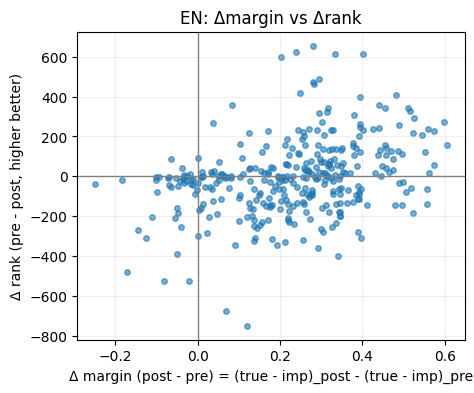

In [39]:
from slanggen.encoder import FTCachedEncoder, dump_vanilla_embeddings

def build_conv_matrix(conv_ds, trainer, fold_name, params):
    conv_texts_all, word_to_indices = [], {}
    for w, wobj in conv_ds.data.items():
        start = len(conv_texts_all)
        defs = wobj.definitions
        for d in defs:
            conv_texts_all.append(d['def'] if isinstance(d, dict) else str(d))
        end = len(conv_texts_all)
        word_to_indices[w] = list(range(start, end))
    conv_mat = trainer.get_testtime_embeddings(conv_texts_all, fold_name=fold_name, model_path=params['embed_name'])
    if isinstance(conv_mat, torch.Tensor):
        conv_mat = conv_mat.detach().cpu().numpy().astype(np.float32)
    else:
        conv_mat = np.asarray(conv_mat).astype(np.float32)
    return conv_mat, word_to_indices

def collect_deltas_margin(dataset, conv_ds, slang_inds, model_pre, fold_pre, model_post, fold_post, params, topk_print=10, max_samples=None, seed=0):
    rng = np.random.default_rng(seed)
    test_ids = slang_inds.test
    if max_samples is not None and max_samples < len(test_ids):
        test_ids = rng.choice(test_ids, size=max_samples, replace=False)

    res_pre  = model_pre.get_results(fold_name=fold_pre,  mode='test', params=params)
    res_post = model_post.get_results(fold_name=fold_post, mode='test', params=params)
    labels = dataset.vocab_ids[slang_inds.test]
    rankings_pre  = get_rankings(res_pre,  np.arange(len(labels)), labels)
    rankings_post = get_rankings(res_post, np.arange(len(labels)), labels)

    slang_texts = [dataset.slang_data[i].def_sent for i in test_ids]
    sl_pre = model_pre.trainer.get_testtime_embeddings(slang_texts, fold_name=fold_pre,  model_path=params['embed_name'])
    sl_post = model_post.trainer.get_testtime_embeddings(slang_texts, fold_name=fold_post, model_path=params['embed_name'])
    for arr_name in ['sl_pre','sl_post']:
        arr = locals()[arr_name]
        if isinstance(arr, torch.Tensor):
            locals()[arr_name] = arr.detach().cpu().numpy().astype(np.float32)
        else:
            locals()[arr_name] = np.asarray(arr).astype(np.float32)

    conv_pre_mat, word_to_inds = build_conv_matrix(conv_ds, model_pre.trainer,  fold_pre,  params)
    conv_post_mat, _            = build_conv_matrix(conv_ds, model_post.trainer, fold_post, params)

    rows = []
    test_ids_list = list(test_ids)
    for local_i, idx in enumerate(test_ids_list):
        entry = dataset.slang_data[idx]
        w = entry.word
        true_inds = word_to_inds.get(w, [])
        if not true_inds: 
            continue

        sim_all_pre  = sl_pre[local_i].dot(conv_pre_mat.T)
        true_pre     = float(np.max(sim_all_pre[true_inds]))
        sim_all_mask = sim_all_pre.copy(); sim_all_mask[true_inds] = -1e9
        imp_pre      = float(np.max(sim_all_mask))
        margin_pre   = true_pre - imp_pre

        sim_all_post  = sl_post[local_i].dot(conv_post_mat.T)
        true_post     = float(np.max(sim_all_post[true_inds]))
        sim_all_mask2 = sim_all_post.copy(); sim_all_mask2[true_inds] = -1e9
        imp_post      = float(np.max(sim_all_mask2))
        margin_post   = true_post - imp_post

        global_pos = int(np.where(slang_inds.test == idx)[0][0])
        rank_pre  = int(rankings_pre[global_pos])
        rank_post = int(rankings_post[global_pos])

        rows.append({
            'idx': int(idx),
            'word': str(w),
            'true_pre': true_pre, 'true_post': true_post,
            'imp_pre': imp_pre,   'imp_post': imp_post,
            'margin_pre': margin_pre, 'margin_post': margin_post,
            'delta_margin': margin_post - margin_pre,
            'rank_pre': rank_pre, 'rank_post': rank_post,
            'delta_rank': rank_pre - rank_post
        })

    df = pd.DataFrame(rows)
    s_rho, s_p = spearmanr(df['delta_margin'], df['delta_rank'])
    print(f"Spearman(Δmargin, Δrank)={s_rho:.3f} (p={s_p:.1e})")

    top_mg = df.reindex(df['delta_margin'].abs().sort_values(ascending=False).index)[:topk_print]
    top_rk = df.reindex(df['delta_rank'].abs().sort_values(ascending=False).index)[:topk_print]
    print(f"Top {topk_print} by |Δmargin|:\n", top_mg[['word','delta_margin','rank_pre','rank_post']])
    print(f"\nTop {topk_print} by |Δrank|:\n", top_rk[['word','delta_rank','margin_pre','margin_post']])
    return df

def prepare_pre_fold(trainer, model_cls, slang_inds, fold_base, params):
    fold_pre = f'{fold_base}_pre'
    dump_vanilla_embeddings(trainer, slang_inds, fold_name=fold_pre, embed_name=params['embed_name'])
    model_pre = model_cls(trainer, data_dir=trainer.out_dir, embed_name=params['embed_name'])
    model_pre.train_categorization(slang_inds, fold_name=fold_pre, params=params)
    model_pre.predict_testset(slang_inds, fold_name=fold_pre, params=params)
    return model_pre, fold_pre

def prepare_post_fold(trainer, model_cls, slang_inds, fold_base, params, student_ckpt_path):
    fold_post = fold_base
    sb_dir = os.path.join(trainer.out_dir, fold_post, 'SBERT_data')
    os.makedirs(sb_dir, exist_ok=True)
    dst_ckpt = os.path.join(sb_dir, f"{params['embed_name']}_multilingual_distilled.pt")
    if not os.path.exists(dst_ckpt):
        copyfile(student_ckpt_path, dst_ckpt)
    trainer.get_trained_embeddings(slang_inds, fold_name=fold_post, model_path=params['embed_name'])
    model_post = model_cls(trainer, data_dir=trainer.out_dir, embed_name=params['embed_name'])
    model_post.train_categorization(slang_inds, fold_name=fold_post, params=params)
    model_post.predict_testset(slang_inds, fold_name=fold_post, params=params)
    return model_post, fold_post

def plot_deltas_margin(df, title='EN'):
    plt.figure(figsize=(5,4))
    plt.scatter(df['delta_margin'], df['delta_rank'], s=16, alpha=0.6)
    plt.axhline(0, color='gray', lw=1); plt.axvline(0, color='gray', lw=1)
    plt.xlabel('Δ margin (post - pre) = (true - imp)_post - (true - imp)_pre')
    plt.ylabel('Δ rank (pre - post, higher better)')
    plt.title(f'{title}: Δmargin vs Δrank')
    plt.grid(alpha=0.2)
    plt.show()
    
student_ckpt_path = os.path.join(out_dir, 'student', 'SBERT_data', 'SBERT_mpnet_multilingual_distilled.pt')

trainer_pre_en = SlangGenTrainer(OSD_wn_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
trainer_post_en = SlangGenTrainer(OSD_wn_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)

model_cls = SlangGenModel
fold_base_en = 'test_en'

# pre
model_pre_en, fold_pre_en = prepare_pre_fold(trainer_pre_en, model_cls, slang_inds_osd, fold_base_en, params)
# post
model_post_en, fold_post_en = prepare_post_fold(trainer_post_en, model_cls, slang_inds_osd, fold_base_en, params, student_ckpt_path)
    
df_en = collect_deltas_margin(OSD_wn_data, wn_data, slang_inds_osd,
                              model_pre_en, fold_pre_en,
                              model_post_en, fold_post_en,
                              params, topk_print=10, max_samples=500, seed=0)
plot_deltas_margin(df_en, 'EN')

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[Vanilla baseline saved] Results/test_zh_pre/sum_embed_SBERT_mpnet_with_head.npz
[Vanilla checkpoint saved] Results/test_zh_pre/SBERT_data/SBERT_mpnet_with_head.pt
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 58.91it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1304.60it/s]


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 43.00it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1172.58it/s]


Cleared GPU cache before loading model
Spearman(Δmargin, Δrank)=-0.098 (p=4.0e-01)
Top 10 by |Δmargin|:
     word  delta_margin  rank_pre  rank_post
68  二十一遥     -0.417607         1          1
40   家庭号     -0.337673         1          1
25   哈韩族     -0.303246         1          1
34   二进宫     -0.288452         1          1
54     捯     -0.272951         1          1
0    不忿儿     -0.269662         1         59
59    门脸     -0.267943         1          1
21   大块头     -0.261490         1          1
33    蹚道     -0.242914         1          1
17   看堆儿     -0.240363         1          1

Top 10 by |Δrank|:
      word  delta_rank  margin_pre  margin_post
73     人脉        -248   -0.063143    -0.136043
37    不搭脉        -210   -0.277738    -0.282731
49    口头禅        -206   -0.254348    -0.138937
66     逃票        -134   -0.147327    -0.143253
14  老模砢碜眼        -111   -0.327425    -0.168632
51     脉门        -108    0.000305    -0.114468
63    肝儿颤        -105   -0.041121    -0.078822
74     雏儿     

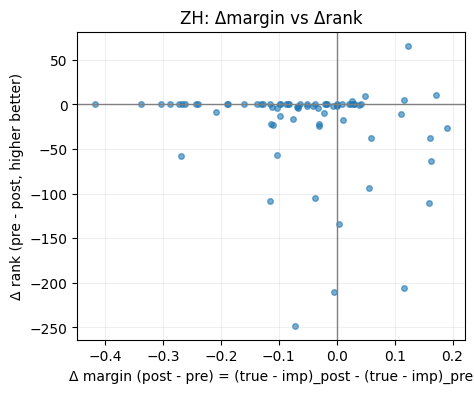

In [40]:
student_ckpt_path = os.path.join(out_dir, 'student', 'SBERT_data', 'SBERT_mpnet_multilingual_distilled.pt')

trainer_pre_zh = SlangGenTrainer(zh_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
trainer_post_zh = SlangGenTrainer(zh_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)

model_cls = SlangGenModel
fold_base_zh = 'test_zh'

# pre
model_pre_zh, fold_pre_zh = prepare_pre_fold(trainer_pre_zh, model_cls, slang_inds_zh, fold_base_zh, params)
# post
model_post_zh, fold_post_zh = prepare_post_fold(trainer_post_zh, model_cls, slang_inds_zh, fold_base_zh, params, student_ckpt_path)

# collect + plot
df_zh = collect_deltas_margin(zh_data, zh_conv_data, slang_inds_zh,
                               model_pre_zh, fold_pre_zh,
                               model_post_zh, fold_post_zh,
                               params, topk_print=10, max_samples=500, seed=0)
plot_deltas_margin(df_zh, 'ZH')

/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[Vanilla baseline saved] Results/test_ru_pre/sum_embed_SBERT_mpnet_with_head.npz
[Vanilla checkpoint saved] Results/test_ru_pre/SBERT_data/SBERT_mpnet_with_head.pt
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 19.18it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 829.41it/s]


Cleared GPU cache before loading model
Encoding sense definitions...
Complete!
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 16.57it/s]


Params: {'embed_name': 'SBERT_mpnet', 'out_name': 'predictions', 'model': 'prototype', 'prior': None, 'prior_name': 'uniform', 'contr_params': None}
Pre-processing Distances...
Pre-processing Complete!
Optimizing Kernels...


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 242.59it/s]


Cleared GPU cache before loading model
Spearman(Δmargin, Δrank)=0.509 (p=8.8e-11)
Top 10 by |Δmargin|:
             word  delta_margin  rank_pre  rank_post
88      наколоть      0.557689       214         15
116       уебать      0.547880       892        796
69           лох      0.547654       584        133
21    впиздячить      0.542011       863        832
115      коровка      0.523009       781         31
113    завинтить      0.499400       410        103
15   перехуярить      0.483112       890        745
45         мудак      0.476138       497        116
55        наёбка      0.470631       764        564
73        кадрёж      0.470550       402         14

Top 10 by |Δrank|:
                  word  delta_rank  margin_pre  margin_post
115           коровка         750   -0.565678    -0.042669
47               урюк         595   -0.342100    -0.072861
38             сотона         587   -0.561200    -0.119203
14              косой        -525   -0.630298    -0.390611
8    нас

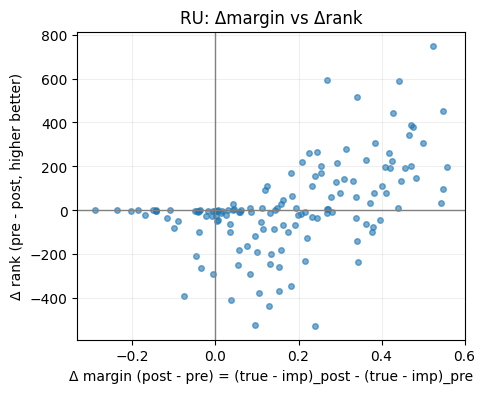

In [41]:
student_ckpt_path = os.path.join(out_dir, 'student', 'SBERT_data', 'SBERT_mpnet_multilingual_distilled.pt')

trainer_pre_ru = SlangGenTrainer(ru_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)
trainer_post_ru = SlangGenTrainer(ru_data, word_encoder=ft_encoder, out_dir=out_dir, verbose=True)

model_cls = SlangGenModel
fold_base_ru = 'test_ru'

# pre
model_pre_ru, fold_pre_ru = prepare_pre_fold(trainer_pre_ru, model_cls, slang_inds_ru, fold_base_ru, params)
# post
model_post_ru, fold_post_ru = prepare_post_fold(trainer_post_ru, model_cls, slang_inds_ru, fold_base_ru, params, student_ckpt_path)

# collect + plot
df_ru = collect_deltas_margin(ru_data, ru_conv_data, slang_inds_ru,
                       model_pre_ru, fold_pre_ru,
                       model_post_ru, fold_post_ru,
                       params, topk_print=10, max_samples=500, seed=0)
plot_deltas_margin(df_ru, 'RU')